In [ ]:
#@title Let's check if we are using the GPU. If not, go to **Runtime** $\rightarrow$ **Change runtime type** $\rightarrow$ **T4 GPU**
import sys
if 'google.colab' in sys.modules:
    from IPython import get_ipython
    get_ipython().system('nvidia-smi')

In [ ]:
#@title Install required libraries
import sys
if 'google.colab' in sys.modules:
    from IPython import get_ipython
    get_ipython().system('pip install -qq -U diffusers==0.32.2 transformers==4.49.0 accelerate==1.5.1 scipy==1.15.2 safetensors==0.5.3 invisible_watermark>=0.2.0')

In [ ]:
#@title Download **Text-to-image** model
import torch
from diffusers import DiffusionPipeline, DPMSolverMultistepScheduler

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
dtype = torch.float16 if device == "cuda" else torch.float32

repo_id = "stabilityai/stable-diffusion-xl-base-1.0"
pipe = DiffusionPipeline.from_pretrained(
    repo_id,
    torch_dtype=dtype,
    use_safetensors=True,
    variant="fp16" if device == "cuda" else None,
)

pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)
pipe = pipe.to(device)

/Users/fbi005/miniconda3/envs/diffusion/lib/python3.11/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/Users/fbi005/miniconda3/envs/diffusion/lib/python3.11/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <EB3FF92A-5EB1-3EE8-AF8B-5923C1265422> /Users/fbi005/miniconda3/envs/diffusion/lib/python3.11/site-packages/torchvision/image.so
  Reason: tried: '/Users/fbi005/miniconda3/envs/diffusion/lib/python3.11/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/fbi005/miniconda3/envs/diffusion/lib/python3.11/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/fbi005/miniconda3/envs/diffusion/lib/python3.11/lib-dynload/../../libjpeg.9.dylib' (no such file), '/Users/fbi005/miniconda3/envs/diffusion/bin/../lib/libjpeg.9.dylib' (no such file)'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warnin

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

/Users/fbi005/miniconda3/envs/diffusion/lib/python3.11/site-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


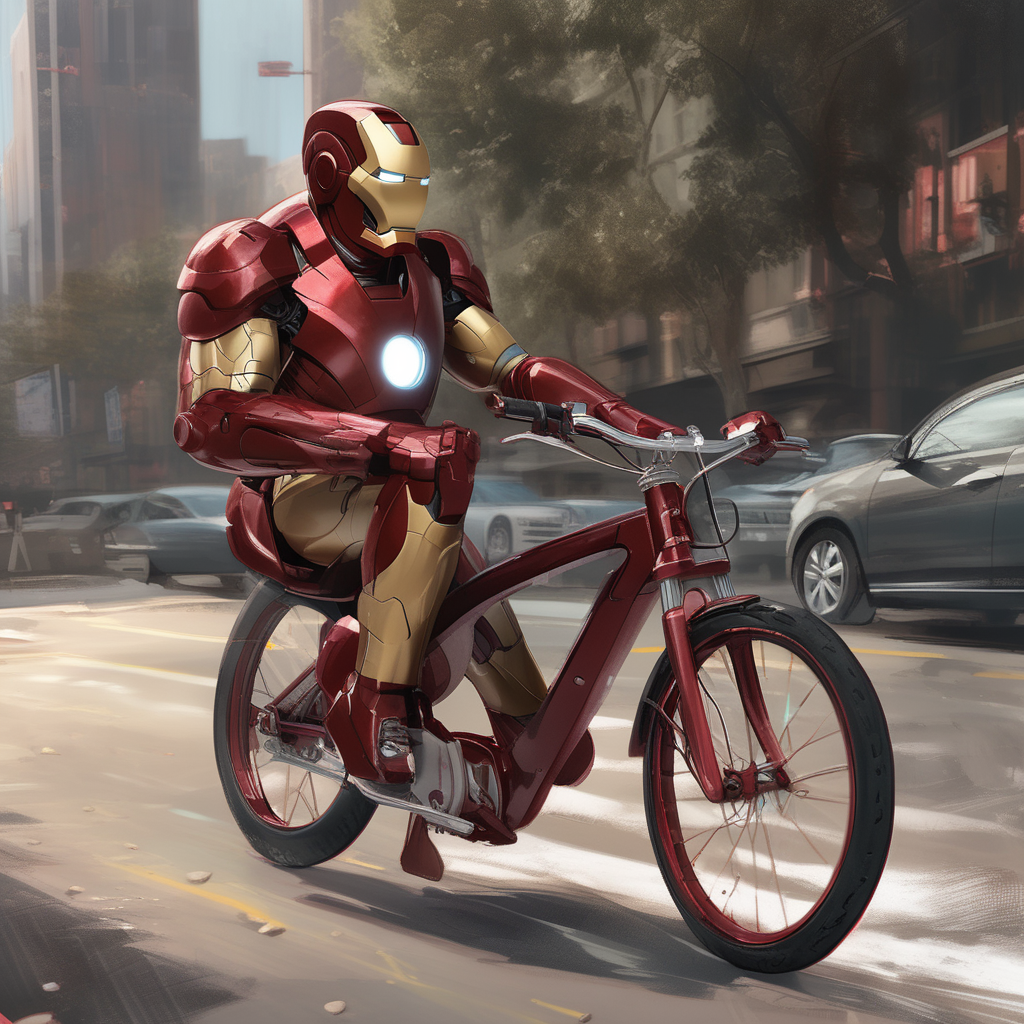

In [4]:
prompt = "Iron Man riding a bicycle, highly detailed, beautiful HD quality, digital painting, artstation, smooth, illustration, cinematic lighting" #@param {type:'string'}

image = pipe(prompt).images[0]
image